# Лабораторна робота №1: Лінійна регресія та градієнтний спуск

**Мета:** навчитись реалізовувати лінійну регресію та градієнтний спуск. Побудувати модель, яка за значенням ознаки `x` прогнозує значення `y`, навчити її **класичним (батчевим) градієнтним спуском** на тренувальному наборі та оцінити якість отриманої моделі на незалежному тестовому наборі за функцією втрат Mean Squared Error (MSE).

**Бібліотеки:** numpy, matplotlib — згідно з умовою використано лише стандартні засоби Python та ці дві бібліотеки. Використання pandas, scikit-learn та подібних бібліотек заборонено умовою, тому читання CSV, обчислення метрик, градієнтів та розв'язання нормальних рівнянь реалізовано самостійно.

**Дані:** `lab_1_train.csv` (60 зразків) та `lab_1_test.csv` (40 зразків) — [Google Drive](https://drive.google.com/drive/folders/17Xwk2quPb1gFmjG3KVIoZqChrWdcZ8XS).

**Теоретичний базис:** лекції №1–№4.

---

## 1. Завантаження та підготовка даних

Кожен файл містить три колонки: `,x,y`. **Перша колонка — це просто індекс рядка, а не ознака**, тому для навчання вона не використовується: як ознаку беремо колонку `x`, як цільову змінну — колонку `y`.

In [1]:
# Імпорт модуля os для роботи зі шляхами до файлів даних
import os

# Імпорт бібліотеки NumPy для роботи з масивами та векторизованими обчисленнями
import numpy as np

# Імпорт модуля matplotlib.pyplot для побудови графіків та візуалізацій
import matplotlib.pyplot as plt

# Вмикаємо відображення графіків безпосередньо в ноутбуці
%matplotlib inline

# Фіксуємо seed генератора випадкових чисел для повної відтворюваності результатів
np.random.seed(42)

# Єдиний стиль оформлення графіків для всього ноутбука
plt.rcParams['figure.dpi'] = 110        # роздільність фігур (щоб підписи були чіткими)
plt.rcParams['font.size'] = 11          # базовий розмір шрифту
plt.rcParams['axes.grid'] = True        # сітка на всіх графіках
plt.rcParams['grid.alpha'] = 0.3        # сітка напівпрозора, щоб не перекривала дані

# Виводимо версії бібліотек — фіксуємо оточення, в якому ноутбук був виконаний
print(f"NumPy:      {np.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")

NumPy:      2.2.6
Matplotlib: 3.11.0


In [2]:
# --- Читання CSV-файлів без pandas ---

# Список каталогів, у яких шукаємо файли даних.
# Такий перебір дозволяє виконати ноутбук без змін і локально, і в Google Colab, і на Kaggle.
SEARCH_DIRS = [
    'data',                      # локальний запуск: файли у підкаталозі ./data
    '.',                         # файли лежать поруч із ноутбуком
    '/content',                  # Google Colab: файли завантажені у сесію
    '/kaggle/input/lab-1',       # Kaggle: приєднаний датасет
]


def find_file(filename):
    """Повертає шлях до файлу даних, знайденого в одному з каталогів SEARCH_DIRS."""
    # Послідовно перебираємо каталоги-кандидати
    for d in SEARCH_DIRS:
        path = os.path.join(d, filename)
        # Якщо файл існує — повертаємо перший знайдений шлях
        if os.path.exists(path):
            return path
    # Якщо ніде не знайшли — повідомляємо зрозумілою помилкою, а не падаємо всередині numpy
    raise FileNotFoundError(
        f"Не знайдено {filename}. Покладіть файл в один із каталогів: {SEARCH_DIRS}"
    )


def load_xy(filename):
    """Читає CSV-файл і повертає два масиви: ознаку x та цільову змінну y."""
    # np.genfromtxt читає числові дані з текстового файлу:
    #   delimiter=',' — роздільник колонок,
    #   skip_header=1 — пропускаємо рядок заголовка ",x,y"
    raw = np.genfromtxt(find_file(filename), delimiter=',', skip_header=1)

    # raw має форму (кількість рядків, 3): колонка 0 — індекс, 1 — x, 2 — y.
    # Колонку 0 (індекс) свідомо НЕ використовуємо — вона не є ознакою.
    x = raw[:, 1]   # ознака
    y = raw[:, 2]   # цільова змінна (те, що прогнозуємо)
    return x, y


# Завантажуємо тренувальний набір — саме на ньому (і лише на ньому) навчатиметься модель
x_train, y_train = load_xy('lab_1_train.csv')

# Завантажуємо тестовий набір — він використовується ВИКЛЮЧНО для перевірки якості
# вже натренованої моделі й жодним чином не впливає на підбір ваг
x_test, y_test = load_xy('lab_1_test.csv')

# Виводимо розміри завантажених вибірок
print(f"Тренувальна вибірка: {x_train.shape[0]} зразків")
print(f"Тестова вибірка:     {x_test.shape[0]} зразків")

# Перевіряємо відсутність пропущених значень (genfromtxt позначає їх як NaN)
print(f"\nПропущені значення (train): {np.isnan(x_train).sum() + np.isnan(y_train).sum()}")
print(f"Пропущені значення (test):  {np.isnan(x_test).sum() + np.isnan(y_test).sum()}")

# Виводимо перші 5 пар (x, y) тренувального набору для наочності
print("\nПерші 5 зразків тренувального набору:")
for i in range(5):
    print(f"  x = {x_train[i]:.6f}   y = {y_train[i]:.6f}")

Тренувальна вибірка: 60 зразків
Тестова вибірка:     40 зразків

Пропущені значення (train): 0
Пропущені значення (test):  0

Перші 5 зразків тренувального набору:
  x = 0.000000   y = 20.149014
  x = 0.010101   y = 19.978723
  x = 0.020202   y = 20.234711
  x = 0.030303   y = 20.517515
  x = 0.040404   y = 20.010562


In [3]:
# --- Описова статистика обох вибірок ---

def describe(name, x, y):
    """Друкує основні статистики ознаки x та цільової змінної y."""
    print(f"{name}:")
    # Діапазон ознаки x — показує, яку область простору ознак покриває вибірка
    print(f"  x: min = {x.min():.4f}   max = {x.max():.4f}   "
          f"mean = {x.mean():.4f}   std = {x.std():.4f}")
    # Розподіл цільової змінної y
    print(f"  y: min = {y.min():.4f}   max = {y.max():.4f}   "
          f"mean = {y.mean():.4f}   std = {y.std():.4f}")


# Порівнюємо статистики тренувальної та тестової вибірок
describe("Тренувальна вибірка", x_train, y_train)
print()
describe("Тестова вибірка", x_test, y_test)

# Перевіряємо крок сітки значень x — чи є дані рівномірною сіткою
step_train = np.diff(x_train)   # різниці між сусідніми значеннями x
print(f"\nКрок по x у train: {step_train.min():.8f} ... {step_train.max():.8f} "
      f"(рівномірний: {np.allclose(step_train, step_train[0])})")

# ВАЖЛИВЕ СПОСТЕРЕЖЕННЯ: діапазони x у вибірках не перетинаються.
# Train покриває ліву частину діапазону, test — праву:
print(f"\nДіапазон x у train: [{x_train.min():.4f}, {x_train.max():.4f}]")
print(f"Діапазон x у test:  [{x_test.min():.4f}, {x_test.max():.4f}]")
print("Вибірки розділені за значенням x, а не випадково, отже перевірка на test —")
print("це перевірка здатності моделі до ЕКСТРАПОЛЯЦІЇ за межі навчальних даних.")

# Коефіцієнт кореляції Пірсона між x та y показує силу лінійного зв'язку.
# Значення, близьке до 1, підтверджує доцільність саме лінійної моделі.
corr = np.corrcoef(x_train, y_train)[0, 1]
print(f"\nКоефіцієнт кореляції Пірсона r(x, y) на train: {corr:.4f}")

Тренувальна вибірка:
  x: min = 0.0000   max = 0.5960   mean = 0.2980   std = 0.1749
  y: min = 19.6886   max = 21.4846   mean = 20.5496   std = 0.4392

Тестова вибірка:
  x: min = 0.6061   max = 1.0000   mean = 0.8030   std = 0.1166
  y: min = 20.7090   max = 22.1290   mean = 21.5978   std = 0.3472

Крок по x у train: 0.01010101 ... 0.01010101 (рівномірний: True)

Діапазон x у train: [0.0000, 0.5960]
Діапазон x у test:  [0.6061, 1.0000]
Вибірки розділені за значенням x, а не випадково, отже перевірка на test —
це перевірка здатності моделі до ЕКСТРАПОЛЯЦІЇ за межі навчальних даних.

Коефіцієнт кореляції Пірсона r(x, y) на train: 0.7882


## 2. Візуалізація тренувальних даних

Згідно з пунктом завдання будуємо графік даних із `lab_1_train.csv`. Точковий графік (scatter plot) дозволяє оцінити, чи справді між `x` та `y` є лінійна залежність і наскільки сильний шум у даних.

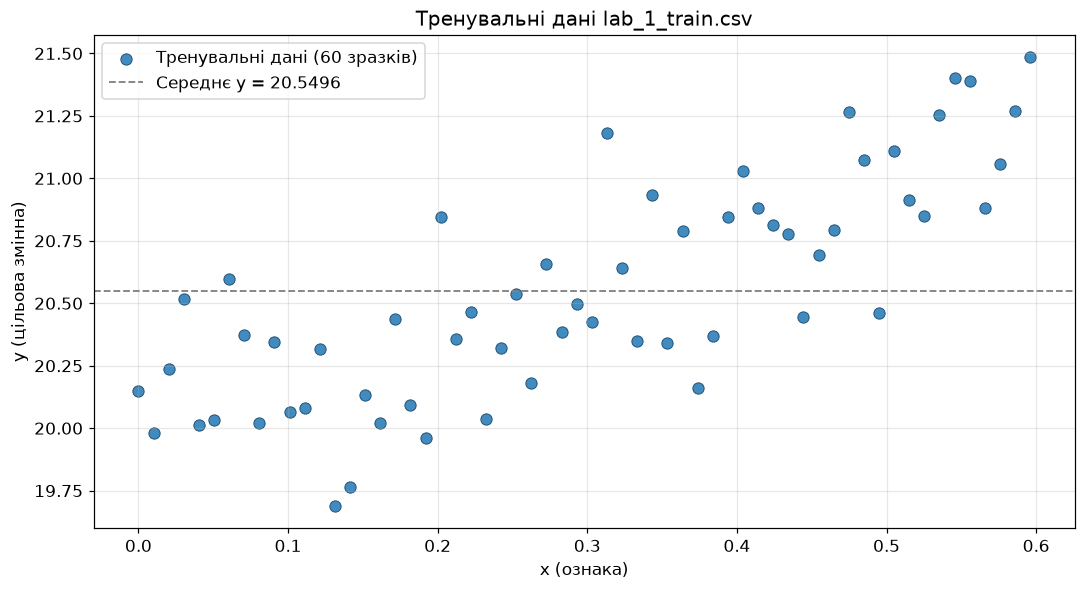

Дані демонструють зростаючий лінійний тренд із шумом.
Розмах y: 1.7959 при std(y) = 0.4392


In [4]:
# --- Візуалізація даних з lab_1_train.csv ---

# Створюємо фігуру розміром 10x5.5 дюймів
plt.figure(figsize=(10, 5.5))

# Точковий графік тренувальних даних:
#   s=55 — площа маркера, alpha=0.85 — легка прозорість (видно накладання точок),
#   edgecolors — темна обводка маркерів для кращої читабельності
plt.scatter(x_train, y_train, s=55, alpha=0.85, color='#1f77b4',
            edgecolors='#0d3c61', linewidths=0.6, label='Тренувальні дані (60 зразків)')

# Горизонтальна лінія на рівні середнього значення y — базовий рівень для порівняння:
# це прогноз найпростішої моделі, яка завжди повертає mean(y)
plt.axhline(y_train.mean(), color='gray', linestyle='--', linewidth=1.2,
            label=f'Середнє y = {y_train.mean():.4f}')

# Підписи осей та заголовок
plt.xlabel('x (ознака)')
plt.ylabel('y (цільова змінна)')
plt.title('Тренувальні дані lab_1_train.csv')
plt.legend()

# tight_layout прибирає зрізання підписів по краях фігури
plt.tight_layout()
plt.show()

# Числовий висновок зі графіка: дані зростають, але з помітним розсіюванням
print(f"Дані демонструють зростаючий лінійний тренд із шумом.")
print(f"Розмах y: {y_train.max() - y_train.min():.4f} при std(y) = {y_train.std():.4f}")

## 3. Модель лінійної регресії та функція втрат MSE

**Модель.** У лекції гіпотеза записується як $h_\theta(x) = \sum_{i=0}^{n} \theta_i x_i$, де $x_0 = 1$, тобто вільний член — це нульова вага $\theta_0$. Для однієї ознаки це звичайна пряма:

$$h_\theta(x) = \theta_0 + \theta_1 x$$

У коді ваги названо `b` та `w`, бо так читабельніше: $b = \theta_0$ — зсув, $w = \theta_1$ — нахил.

**Функція втрат.** У лекції функція вартості записана як

$$J(\theta) = \frac{1}{2} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2$$

Умова лабораторної вимагає використати саме **Mean Squared Error**, тобто середнє, а не половину суми:

$$J(w, b) = \frac{1}{n} \sum_{i=1}^{n} \left( w x_i + b - y_i \right)^2$$

Ці два записи відрізняються лише сталим множником $\frac{2}{n}$: половина в лекційній формулі стоїть для того, щоб скоротити двійку під час диференціювання. Стала перед сумою не змінює положення мінімуму — вона лише масштабує градієнт, а отже й потрібний темп навчання. Далі всюди використовується MSE, як вимагає умова.

**Градієнт.** Виведення повторює лекційне, тільки для MSE. Для одного зразка:

$$\frac{\partial}{\partial \theta_j} J(\theta)
= \frac{\partial}{\partial \theta_j} \frac{1}{2} \left( h_\theta(x) - y \right)^2
= 2 \cdot \frac{1}{2} \left( h_\theta(x) - y \right) \cdot \frac{\partial}{\partial \theta_j} \left( h_\theta(x) - y \right)
= \left( h_\theta(x) - y \right) x_j$$

У MSE половини немає, а є ділення на $n$, тому двійка не скорочується й лишається в чисельнику:

$$\frac{\partial J}{\partial w} = \frac{2}{n} \sum_{i=1}^{n} \left( w x_i + b - y_i \right) x_i, \qquad
\frac{\partial J}{\partial b} = \frac{2}{n} \sum_{i=1}^{n} \left( w x_i + b - y_i \right)$$

Похідна за $b$ виходить із тієї самої формули, якщо згадати, що $b$ — це вага при сталій ознаці $x_0 = 1$.

Функція $J(w,b)$ квадратична та **строго випукла**, тому вона має єдиний глобальний мінімум — локальних мінімумів, у яких міг би застрягти градієнтний спуск, тут не існує.

In [5]:
# --- Реалізація моделі, функції втрат та її градієнта ---

def predict(x, w, b):
    """Прогноз лінійної моделі: y_hat = w * x + b (векторизовано для всього масиву x)."""
    return w * x + b


def mse_loss(x, y, w, b):
    """Функція втрат Mean Squared Error: середній квадрат помилки прогнозу."""
    # Вектор помилок: різниця між прогнозом та істинним значенням для кожного зразка
    errors = predict(x, w, b) - y
    # Середнє значення квадратів помилок
    return np.mean(errors ** 2)


def mse_gradient(x, y, w, b):
    """Градієнт MSE за вагами w та b — аналітичні формули, виведені вище."""
    # n — кількість зразків у вибірці
    n = x.shape[0]
    # Вектор помилок (той самий, що й у функції втрат)
    errors = predict(x, w, b) - y
    # Частинна похідна за w: (2/n) * сума(помилка_i * x_i)
    dw = (2.0 / n) * np.sum(errors * x)
    # Частинна похідна за b: (2/n) * сума(помилка_i)
    db = (2.0 / n) * np.sum(errors)
    return dw, db


# --- Перевірка коректності аналітичного градієнта ---
# Порівнюємо аналітичну похідну з чисельною, обчисленою центральною різницею:
#   dJ/dw ≈ [J(w + h) - J(w - h)] / (2h)
# Якщо формули градієнта виведені правильно, значення збігатимуться до ~1e-9.
w_chk, b_chk, h = 1.5, 18.0, 1e-6

# Аналітичний градієнт за нашими формулами
dw_analytic, db_analytic = mse_gradient(x_train, y_train, w_chk, b_chk)

# Чисельна оцінка похідної за w
dw_numeric = (mse_loss(x_train, y_train, w_chk + h, b_chk)
              - mse_loss(x_train, y_train, w_chk - h, b_chk)) / (2 * h)

# Чисельна оцінка похідної за b
db_numeric = (mse_loss(x_train, y_train, w_chk, b_chk + h)
              - mse_loss(x_train, y_train, w_chk, b_chk - h)) / (2 * h)

print("Перевірка градієнта (аналітичний проти чисельного):")
print(f"  dJ/dw: аналітично = {dw_analytic:.10f}, чисельно = {dw_numeric:.10f}, "
      f"різниця = {abs(dw_analytic - dw_numeric):.2e}")
print(f"  dJ/db: аналітично = {db_analytic:.10f}, чисельно = {db_numeric:.10f}, "
      f"різниця = {abs(db_analytic - db_numeric):.2e}")
print("\nГрадієнт реалізовано правильно — різниці на рівні похибки округлення.")

Перевірка градієнта (аналітичний проти чисельного):
  dJ/dw: аналітично = -1.2823630011, чисельно = -1.2823630007, різниця = 4.50e-10
  dJ/db: аналітично = -4.2051869881, чисельно = -4.2051869928, різниця = 4.71e-09

Градієнт реалізовано правильно — різниці на рівні похибки округлення.


## 4. Батчевий градієнтний спуск

Правило оновлення ваг із лекції:

$$\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j} J(\theta)$$

де $\alpha$ — темп навчання (learning rate). У наших позначеннях це:

$$w \leftarrow w - \alpha \frac{\partial J}{\partial w}, \qquad b \leftarrow b - \alpha \frac{\partial J}{\partial b}$$

Для всієї вибірки одразу в лекції записано так:

$$\theta_j := \theta_j + \alpha \sum_{i=1}^{m} \left( y^{(i)} - h_\theta(x^{(i)}) \right) x_j^{(i)}$$

Знак «плюс» перед сумою разом із порядком $\left(y - h_\theta(x)\right)$ дає те саме, що «мінус» перед $\left(h_\theta(x) - y\right)$ — це один і той самий крок, просто інакше записаний. Відмінність лише в тому, що ми додатково ділимо на $n$, бо працюємо з MSE, а в лекції стоїть чиста сума.

Саме цей варіант — одне оновлення по всій вибірці — і є **класичним (батчевим)** градієнтним спуском, якого вимагає умова: градієнт обчислюється по **всій** тренувальній вибірці одразу, і за одну епоху виконується **рівно одне** оновлення ваг. Це відрізняє його від:

- **стохастичного** (SGD) — одне оновлення на кожен окремий зразок, тобто $n$ оновлень за епоху;
- **мінібатчевого** — одне оновлення на групу зразків, тобто $n/\text{batch\_size}$ оновлень за епоху.

**Критерій зупинки.** Спуск вважаємо таким, що зійшовся, коли норма градієнта стає меншою за поріг:

$$\|\nabla J\|_2 = \sqrt{\left(\tfrac{\partial J}{\partial w}\right)^2 + \left(\tfrac{\partial J}{\partial b}\right)^2} < \varepsilon$$

Цей критерій кращий за перевірку зміни втрат $|J_{k} - J_{k-1}| < \varepsilon$, бо норма градієнта прямо вимірює відстань до точки мінімуму (у мінімумі градієнт строго нульовий), тоді як зміна втрат може бути малою й через занадто дрібний крок.

**Початкові значення ваг** беремо нульовими ($w_0 = b_0 = 0$): для строго випуклої задачі точка старту не впливає на кінцевий результат, лише на кількість епох.

In [6]:
# --- Реалізація батчевого градієнтного спуску ---

def gradient_descent(x, y, alpha, eps=1e-6, max_epochs=100000,
                     w_init=0.0, b_init=0.0, verbose=True):
    """
    Класичний (батчевий) градієнтний спуск для лінійної регресії.

    Параметри:
        x, y        — тренувальні дані (ознака та цільова змінна);
        alpha       — темп навчання;
        eps         — поріг для норми градієнта (критерій збіжності);
        max_epochs  — обмеження на кількість епох (захист від нескінченного циклу);
        w_init, b_init — початкові значення ваг;
        verbose     — чи виводити стан після кожної епохи.

    Повертає: фінальні ваги w, b, історію навчання та ознаку збіжності.
    """
    # Ініціалізуємо ваги початковими значеннями
    w, b = w_init, b_init

    # Списки для збереження історії навчання (для побудови графіків збіжності)
    history = {'epoch': [], 'w': [], 'b': [], 'loss': [], 'grad_norm': []}

    # Прапорець: чи досягнуто критерію збіжності
    converged = False

    # Головний цикл навчання: одна ітерація = одна ЕПОХА = одне оновлення ваг
    for epoch in range(1, max_epochs + 1):

        # КРОК 1. Обчислюємо градієнт по ВСІЙ тренувальній вибірці (батчевий спуск)
        dw, db = mse_gradient(x, y, w, b)

        # КРОК 2. Оновлюємо обидві ваги одночасно, рухаючись проти градієнта.
        # Важливо: спочатку обчислені ОБА компоненти градієнта у старій точці,
        # і лише потім застосовані — інакше друга вага оновлювалась би за вже зміненою першою.
        w = w - alpha * dw
        b = b - alpha * db

        # КРОК 3. Обчислюємо стан моделі ПІСЛЯ оновлення ваг:
        # поточне значення функції втрат та нову норму градієнта
        loss = mse_loss(x, y, w, b)
        dw_new, db_new = mse_gradient(x, y, w, b)
        grad_norm = np.sqrt(dw_new ** 2 + db_new ** 2)

        # КРОК 4. Зберігаємо стан в історію навчання
        history['epoch'].append(epoch)
        history['w'].append(w)
        history['b'].append(b)
        history['loss'].append(loss)
        history['grad_norm'].append(grad_norm)

        # КРОК 5. Згідно з умовою — виводимо поточні значення ваг та функції втрат
        # ПІСЛЯ КОЖНОЇ ЕПОХИ
        if verbose:
            print(f"Епоха {epoch:4d} | w = {w:12.8f} | b = {b:12.8f} | "
                  f"MSE = {loss:14.10f} | ||grad|| = {grad_norm:.3e}")

        # КРОК 6. Перевіряємо критерій збіжності: норма градієнта менша за поріг
        if grad_norm < eps:
            converged = True
            break

        # Захист від розбіжності: якщо втрати стали нескінченними або NaN,
        # темп навчання завеликий і продовжувати немає сенсу
        if not np.isfinite(loss):
            if verbose:
                print(f"\nРОЗБІЖНІСТЬ на епосі {epoch}: темп навчання alpha = {alpha} завеликий.")
            break

    return w, b, history, converged


print("Функцію gradient_descent() визначено.")

Функцію gradient_descent() визначено.


## 5. Навчання моделі

Запускаємо навчання на тренувальних даних. Темп навчання $\alpha = 0.8$ обрано за результатами дослідження з розділу 8 — з перебраної там сітки значень саме воно дає найшвидшу збіжність. Після кожної епохи виводяться поточні значення ваг $w$, $b$ та функції втрат MSE, як вимагає умова.

In [7]:
# --- Навчання моделі батчевим градієнтним спуском ---

# Темп навчання: обґрунтування вибору саме цього значення — у розділі 8
ALPHA = 0.8

# Поріг для норми градієнта, за яким вважаємо, що спуск зійшовся
EPS = 1e-6

# Значення функції втрат та норми градієнта у початковій точці,
# ДО першого оновлення ваг — з ними порівнюємо кінцевий результат
mse_initial = mse_loss(x_train, y_train, 0.0, 0.0)
dw_init, db_init = mse_gradient(x_train, y_train, 0.0, 0.0)
grad_norm_initial = np.sqrt(dw_init ** 2 + db_init ** 2)

print(f"Навчання: alpha = {ALPHA}, критерій збіжності ||grad|| < {EPS:g}, "
      f"початкові ваги w = 0, b = 0")
print(f"MSE у початковій точці (w = 0, b = 0): {mse_initial:.6f}, "
      f"||grad|| = {grad_norm_initial:.4f}")
print("=" * 96)

# Запускаємо градієнтний спуск. Тренування відбувається ЛИШЕ на даних train-датасету.
w_final, b_final, history, converged = gradient_descent(
    x_train, y_train, alpha=ALPHA, eps=EPS
)

print("=" * 96)
print(f"Градієнтний спуск {'ЗІЙШОВСЯ' if converged else 'НЕ зійшовся'} "
      f"за {len(history['epoch'])} епох.")
print(f"\nФінальні ваги моделі:")
print(f"  w = {w_final:.10f}")
print(f"  b = {b_final:.10f}")
print(f"\nОтримана модель: y_hat = {w_final:.6f} * x + {b_final:.6f}")
print(f"Функція втрат MSE на тренувальних даних: {history['loss'][-1]:.10f}")

Навчання: alpha = 0.8, критерій збіжності ||grad|| < 1e-06, початкові ваги w = 0, b = 0
MSE у початковій точці (w = 0, b = 0): 422.477402, ||grad|| = 42.9197
Епоха    1 | w =   9.89425077 | b =  32.87930111 | MSE = 235.4083451779 | ||grad|| = 3.203e+01
Епоха    2 | w =   2.22263336 | b =   8.43446149 | MSE = 131.2415251910 | ||grad|| = 2.390e+01
Епоха    3 | w =   7.67102003 | b =  26.75894447 | MSE =  73.2328001541 | ||grad|| = 1.783e+01
Епоха    4 | w =   3.34209043 | b =  13.16664002 | MSE =  40.9242882174 | ||grad|| = 1.331e+01
Епоха    5 | w =   6.32047956 | b =  23.38591640 | MSE =  22.9257027478 | ||grad|| = 9.929e+00
Епоха    6 | w =   3.85769193 | b =  15.83435091 | MSE =  12.8952665276 | ||grad|| = 7.409e+00
Епоха    7 | w =   5.46570834 | b =  21.53946774 | MSE =   7.3020329839 | ||grad|| = 5.529e+00
Епоха    8 | w =   4.04653310 | b =  17.34974739 | MSE =   4.1800289006 | ||grad|| = 4.127e+00
Епоха    9 | w =   4.89598348 | b =  20.54019649 | MSE =   2.4346066350 | ||grad||

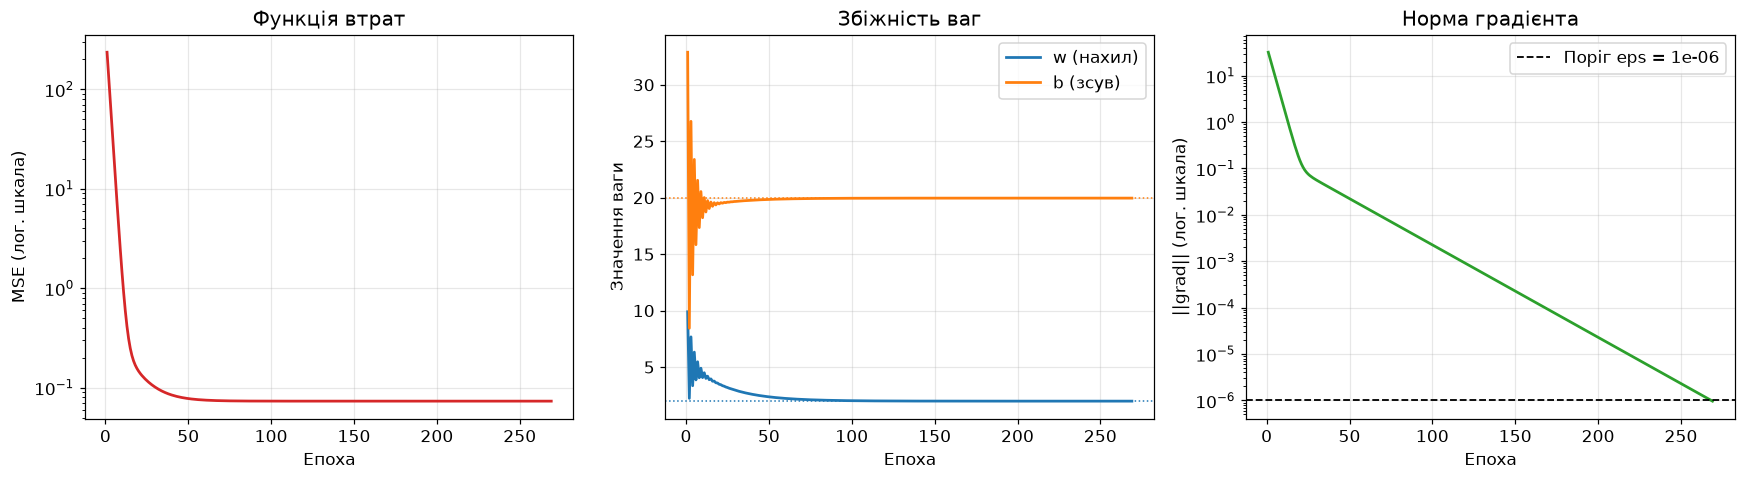

MSE у початковій точці (w = 0, b = 0): 422.477402
MSE після 1-ї епохи:   235.408345
MSE на останній епосі: 0.0730350678

Зменшення втрат від початкової точки: у 5785 разів

Норма градієнта у початковій точці: 42.9197
Норма градієнта: після 1-ї епохи 32.0255 -> на останній 9.639e-07


In [8]:
# --- Графіки збіжності градієнтного спуску ---

# Створюємо фігуру з трьох підграфіків в один рядок
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

epochs = history['epoch']

# --- Підграфік 1: функція втрат за епохами (логарифмічна шкала по Y) ---
# Логарифмічна шкала потрібна, бо MSE падає з ~400 до ~0.07, тобто на 4 порядки
axes[0].plot(epochs, history['loss'], color='#d62728', linewidth=1.8)
axes[0].set_yscale('log')
axes[0].set_xlabel('Епоха')
axes[0].set_ylabel('MSE (лог. шкала)')
axes[0].set_title('Функція втрат')

# --- Підграфік 2: траєкторії ваг за епохами ---
axes[1].plot(epochs, history['w'], label='w (нахил)', color='#1f77b4', linewidth=1.8)
axes[1].plot(epochs, history['b'], label='b (зсув)', color='#ff7f0e', linewidth=1.8)
# Горизонтальні лінії — фінальні значення, до яких зійшлися ваги
axes[1].axhline(w_final, color='#1f77b4', linestyle=':', linewidth=1)
axes[1].axhline(b_final, color='#ff7f0e', linestyle=':', linewidth=1)
axes[1].set_xlabel('Епоха')
axes[1].set_ylabel('Значення ваги')
axes[1].set_title('Збіжність ваг')
axes[1].legend()

# --- Підграфік 3: норма градієнта за епохами ---
# Пряма лінія на лог-шкалі означає геометричну (лінійну) швидкість збіжності
axes[2].plot(epochs, history['grad_norm'], color='#2ca02c', linewidth=1.8)
axes[2].axhline(EPS, color='black', linestyle='--', linewidth=1.2,
                label=f'Поріг eps = {EPS:g}')
axes[2].set_yscale('log')
axes[2].set_xlabel('Епоха')
axes[2].set_ylabel('||grad|| (лог. шкала)')
axes[2].set_title('Норма градієнта')
axes[2].legend()

plt.tight_layout()
plt.show()

# Числові характеристики процесу навчання
print(f"MSE у початковій точці (w = 0, b = 0): {mse_initial:.6f}")
print(f"MSE після 1-ї епохи:   {history['loss'][0]:.6f}")
print(f"MSE на останній епосі: {history['loss'][-1]:.10f}")
print(f"\nЗменшення втрат від початкової точки: "
      f"у {mse_initial / history['loss'][-1]:.0f} разів")
print(f"\nНорма градієнта у початковій точці: {grad_norm_initial:.4f}")
print(f"Норма градієнта: після 1-ї епохи {history['grad_norm'][0]:.4f} "
      f"-> на останній {history['grad_norm'][-1]:.3e}")

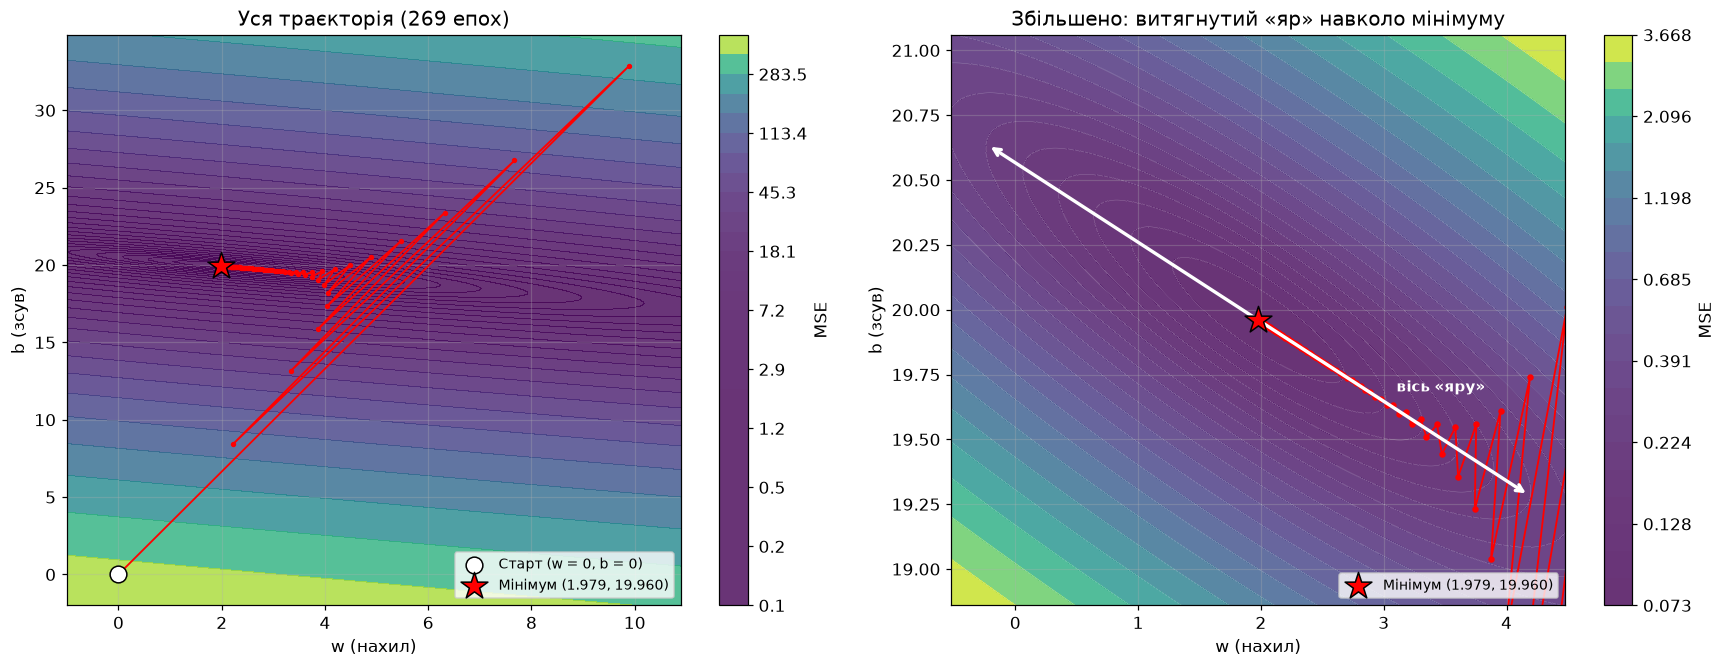

Ліва панель: на перших епохах крок завеликий для найкрутішого напрямку,
тому траєкторія перестрибує мінімум і різко коливається поперек «яру».
Права панель: лінії рівня MSE — сильно витягнуті еліпси; співвідношення
їхніх осей дорівнює sqrt(cond) = 6.24. Уздовж довгої осі
(вісь «яру») поверхня майже пласка, градієнт малий, і спуск сповзає до
мінімуму поволі — саме тому й потрібно 269 епох.

Напрямок яру: (-0.9561, +0.2931) у координатах (w, b),
власні значення гессіана: 0.056078 та 2.182707.
Кількісний аналіз цього явища — у розділі 9.


In [9]:
# --- Траєкторія градієнтного спуску на поверхні функції втрат ---

# Масиви значень ваг за всі епохи; на початок додаємо стартову точку (0, 0)
w_path = np.concatenate([[0.0], np.array(history['w'])])
b_path = np.concatenate([[0.0], np.array(history['b'])])


def loss_surface(w_lo, w_hi, b_lo, b_hi, k=300):
    """Обчислює MSE на сітці значень (w, b) розміром k x k."""
    w_grid = np.linspace(w_lo, w_hi, k)
    b_grid = np.linspace(b_lo, b_hi, k)
    W, B = np.meshgrid(w_grid, b_grid)
    # Векторизоване обчислення через broadcasting:
    # W[..., None] має форму (k, k, 1), x_train — (60,), результат — (k, k, 60)
    J = np.mean((W[..., None] * x_train + B[..., None] - y_train) ** 2, axis=2)
    return W, B, J


fig, axes = plt.subplots(1, 2, figsize=(16, 6.2))

# ═══ Панель 1: уся траєкторія від старту до мінімуму ═══
W1, B1, J1 = loss_surface(min(0, w_path.min()) - 1, w_path.max() + 1,
                          min(0, b_path.min()) - 2, b_path.max() + 2)

# Рівні ліній рівня беремо логарифмічно розподіленими, бо MSE змінюється
# на кілька порядків — за рівномірних рівнів усі лінії злилися б в одну зону
lv1 = np.logspace(np.log10(J1.min() + 1e-3), np.log10(J1.max()), 30)
cs1 = axes[0].contourf(W1, B1, J1, levels=lv1, cmap='viridis', alpha=0.8)
fig.colorbar(cs1, ax=axes[0], label='MSE')

# Траєкторія спуску
axes[0].plot(w_path, b_path, color='red', linewidth=1.2, marker='o', markersize=2.5)
axes[0].scatter([0], [0], color='white', edgecolors='black', s=120, zorder=5,
                label='Старт (w = 0, b = 0)')
axes[0].scatter([w_final], [b_final], color='red', edgecolors='black', marker='*',
                s=340, zorder=5, label=f'Мінімум ({w_final:.3f}, {b_final:.3f})')

axes[0].set_xlabel('w (нахил)')
axes[0].set_ylabel('b (зсув)')
axes[0].set_title(f'Уся траєкторія ({len(history["epoch"])} епох)')
axes[0].legend(loc='lower right', fontsize=9)

# ═══ Панель 2: збільшення області навколо мінімуму ═══
# Розмір вікна задаємо так, щоб було видно витягнутість «яру».
# Напрямок яру — власний вектор гессіана, що відповідає МЕНШОМУ власному
# значенню: саме вздовж нього поверхня майже пласка, тому спуск і повзе поволі.
H_loc = 2 * np.array([[np.mean(x_train ** 2), np.mean(x_train)],
                      [np.mean(x_train),      1.0]])
eigval_loc, eigvec_loc = np.linalg.eigh(H_loc)
valley_dir = eigvec_loc[:, 0]          # вектор напрямку яру (для меншого власного значення)

dw_win, db_win = 2.5, 1.1              # напіврозміри вікна по w та b
W2, B2, J2 = loss_surface(w_final - dw_win, w_final + dw_win,
                          b_final - db_win, b_final + db_win)

lv2 = np.logspace(np.log10(J2.min()), np.log10(J2.max()), 22)
cs2 = axes[1].contourf(W2, B2, J2, levels=lv2, cmap='viridis', alpha=0.8)
axes[1].contour(W2, B2, J2, levels=lv2, colors='white', linewidths=0.4, alpha=0.45)
fig.colorbar(cs2, ax=axes[1], label='MSE')

# Та сама траєкторія, але видно лише її частину, що потрапляє у вікно
axes[1].plot(w_path, b_path, color='red', linewidth=1.2, marker='o', markersize=3.2)
axes[1].scatter([w_final], [b_final], color='red', edgecolors='black', marker='*',
                s=340, zorder=5, label=f'Мінімум ({w_final:.3f}, {b_final:.3f})')

# Стрілка вздовж напрямку яру — наочно показує вісь витягнутості ліній рівня
arrow_len = 0.88 * dw_win / abs(valley_dir[0])      # щоб стрілка вписалась у вікно
axes[1].annotate('', xy=(w_final + arrow_len * valley_dir[0],
                         b_final + arrow_len * valley_dir[1]),
                 xytext=(w_final - arrow_len * valley_dir[0],
                         b_final - arrow_len * valley_dir[1]),
                 arrowprops=dict(arrowstyle='<->', color='white', linewidth=2.2))
axes[1].text(w_final + 0.45 * dw_win, b_final - 0.25 * db_win, 'вісь «яру»',
             color='white', fontsize=10, fontweight='bold')

axes[1].set_xlim(w_final - dw_win, w_final + dw_win)
axes[1].set_ylim(b_final - db_win, b_final + db_win)
axes[1].set_xlabel('w (нахил)')
axes[1].set_ylabel('b (зсув)')
axes[1].set_title('Збільшено: витягнутий «яр» навколо мінімуму')
axes[1].legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

print("Ліва панель: на перших епохах крок завеликий для найкрутішого напрямку,")
print("тому траєкторія перестрибує мінімум і різко коливається поперек «яру».")
print("Права панель: лінії рівня MSE — сильно витягнуті еліпси; співвідношення")
print(f"їхніх осей дорівнює sqrt(cond) = {np.sqrt(eigval_loc[1] / eigval_loc[0]):.2f}. Уздовж довгої осі")
print("(вісь «яру») поверхня майже пласка, градієнт малий, і спуск сповзає до")
print(f"мінімуму поволі — саме тому й потрібно {len(history['epoch'])} епох.")
print(f"\nНапрямок яру: ({valley_dir[0]:+.4f}, {valley_dir[1]:+.4f}) у координатах (w, b),")
print(f"власні значення гессіана: {eigval_loc[0]:.6f} та {eigval_loc[1]:.6f}.")
print("Кількісний аналіз цього явища — у розділі 9.")

## 6. Оцінка якості на тестових даних

Після того, як градієнтний спуск зійшовся, обчислюємо функцію втрат на тестових даних із `lab_1_test.csv`. Тестова вибірка **не використовувалась** під час навчання, тому MSE на ній є незалежною оцінкою якості моделі. Варто одразу зауважити: оскільки вибірки розділені за значенням $x$, а не випадково, ця оцінка характеризує якість моделі саме **при екстраполяції** й не є незміщеною оцінкою помилки на тому самому діапазоні, де модель навчалась.

Додатково до MSE обчислюємо:
- **RMSE** $=\sqrt{MSE}$ — має ту саму розмірність, що й $y$, тому інтерпретується як типова величина помилки прогнозу;
- **коефіцієнт детермінації** $R^2 = 1 - \dfrac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$ — частка дисперсії $y$, яку пояснює модель.

In [10]:
# --- Обчислення функції втрат на тренувальних та тестових даних ---

# MSE на тренувальних даних (на них модель навчалася)
mse_train = mse_loss(x_train, y_train, w_final, b_final)

# MSE на тестових даних — головна метрика якості натренованої моделі
mse_test = mse_loss(x_test, y_test, w_final, b_final)


def r_squared(x, y, w, b):
    """Коефіцієнт детермінації R^2 — частка дисперсії y, яку пояснює модель."""
    # Сума квадратів залишків моделі
    ss_res = np.sum((y - predict(x, w, b)) ** 2)
    # Загальна сума квадратів (відносно середнього значення y)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - ss_res / ss_tot


# Зводимо всі метрики в таблицю
print(f"Модель: y_hat = {w_final:.6f} * x + {b_final:.6f}\n")
print(f"{'Метрика':<12} {'Train':>14} {'Test':>14}")
print("-" * 42)
print(f"{'MSE':<12} {mse_train:>14.10f} {mse_test:>14.10f}")
print(f"{'RMSE':<12} {np.sqrt(mse_train):>14.10f} {np.sqrt(mse_test):>14.10f}")
print(f"{'R^2':<12} {r_squared(x_train, y_train, w_final, b_final):>14.6f} "
      f"{r_squared(x_test, y_test, w_final, b_final):>14.6f}")
print(f"{'Зразків':<12} {len(x_train):>14d} {len(x_test):>14d}")

print(f"\nMSE на тестових даних: {mse_test:.10f}")
print(f"Відношення MSE_test / MSE_train = {mse_test / mse_train:.4f}")

# Щоб оцінити RMSE, порівнюємо його з повним розмахом y по обох вибірках
y_all = np.concatenate([y_train, y_test])
print(f"\nRMSE на тесті = {np.sqrt(mse_test):.6f} при повному розмаху y = "
      f"{y_all.max() - y_all.min():.4f} (від {y_all.min():.4f} до {y_all.max():.4f}),")
print(f"тобто типова помилка прогнозу становить "
      f"{100 * np.sqrt(mse_test) / (y_all.max() - y_all.min()):.1f}% розмаху.")
print("\nТестова помилка лише на кілька відсотків перевищує тренувальну —")
print("отже перенавчання (overfitting) немає, модель добре узагальнює.")

Модель: y_hat = 1.978801 * x + 19.959920

Метрика               Train           Test
------------------------------------------
MSE            0.0730350678   0.0755863635
RMSE           0.2702500099   0.2749297429
R^2                0.621295       0.372940
Зразків                  60             40

MSE на тестових даних: 0.0755863635
Відношення MSE_test / MSE_train = 1.0349

RMSE на тесті = 0.274930 при повному розмаху y = 2.4403 (від 19.6886 до 22.1290),
тобто типова помилка прогнозу становить 11.3% розмаху.

Тестова помилка лише на кілька відсотків перевищує тренувальну —
отже перенавчання (overfitting) немає, модель добре узагальнює.


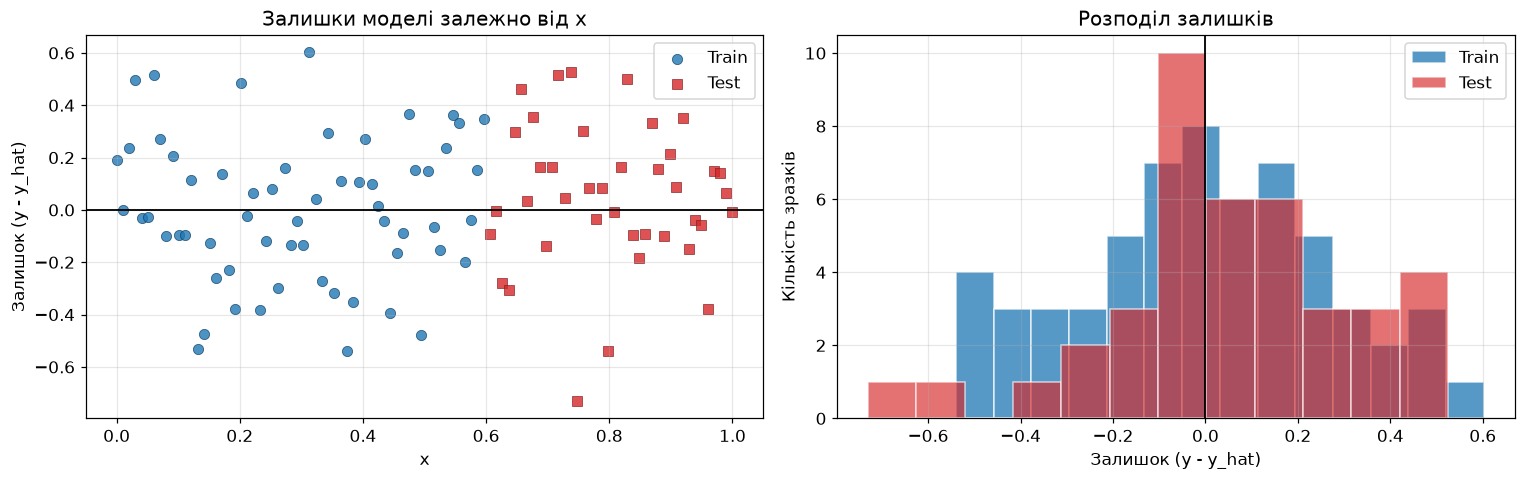

Залишки train: середнє = +1.41e-07, std = 0.270250
Залишки test:  середнє = +4.88e-02, std = 0.270562

Середнє залишків на train практично нульове — це математичний наслідок
умови dJ/db = 0 у точці мінімуму: систематичного зсуву прогнозу немає.
На тесті середнє залишків додатне (+0.0488): модель трохи
занижує прогноз, бо в цій області x вона працює на екстраполяції.
Розсіювання залишків на обох вибірках однакове — форму залежності
модель вловила правильно, тобто недонавчання (underfitting) немає.


In [11]:
# --- Аналіз залишків моделі ---

# Залишок (residual) — різниця між істинним значенням та прогнозом моделі
res_train = y_train - predict(x_train, w_final, b_final)
res_test = y_test - predict(x_test, w_final, b_final)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# --- Підграфік 1: залишки залежно від x ---
# Якщо модель адекватна, залишки хаотично розкидані навколо нуля
# без видимої структури (кривизни, розширення розсіювання тощо)
axes[0].scatter(x_train, res_train, s=45, alpha=0.8, color='#1f77b4',
                edgecolors='#0d3c61', linewidths=0.5, label='Train')
axes[0].scatter(x_test, res_test, s=45, alpha=0.8, color='#d62728',
                marker='s', edgecolors='#7d1a1a', linewidths=0.5, label='Test')
axes[0].axhline(0, color='black', linewidth=1.2)
axes[0].set_xlabel('x')
axes[0].set_ylabel('Залишок (y - y_hat)')
axes[0].set_title('Залишки моделі залежно від x')
axes[0].legend()

# --- Підграфік 2: гістограма розподілу залишків ---
# Симетричний дзвоноподібний розподіл свідчить про нормальність шуму в даних
axes[1].hist(res_train, bins=14, alpha=0.75, color='#1f77b4',
             edgecolor='white', label='Train')
axes[1].hist(res_test, bins=12, alpha=0.65, color='#d62728',
             edgecolor='white', label='Test')
axes[1].axvline(0, color='black', linewidth=1.2)
axes[1].set_xlabel('Залишок (y - y_hat)')
axes[1].set_ylabel('Кількість зразків')
axes[1].set_title('Розподіл залишків')
axes[1].legend()

plt.tight_layout()
plt.show()

# Статистики залишків: середнє має бути близьким до нуля
print(f"Залишки train: середнє = {res_train.mean():+.2e}, std = {res_train.std():.6f}")
print(f"Залишки test:  середнє = {res_test.mean():+.2e}, std = {res_test.std():.6f}")
print("\nСереднє залишків на train практично нульове — це математичний наслідок")
print("умови dJ/db = 0 у точці мінімуму: систематичного зсуву прогнозу немає.")
print(f"На тесті середнє залишків додатне ({res_test.mean():+.4f}): модель трохи")
print("занижує прогноз, бо в цій області x вона працює на екстраполяції.")
print("Розсіювання залишків на обох вибірках однакове — форму залежності")
print("модель вловила правильно, тобто недонавчання (underfitting) немає.")

## 7. Візуалізація результату

Згідно з пунктом завдання будуємо **на одному графіку** дані з `lab_1_train.csv`, дані з `lab_1_test.csv` та лінію, до якої зійшовся розв'язок градієнтного спуску.

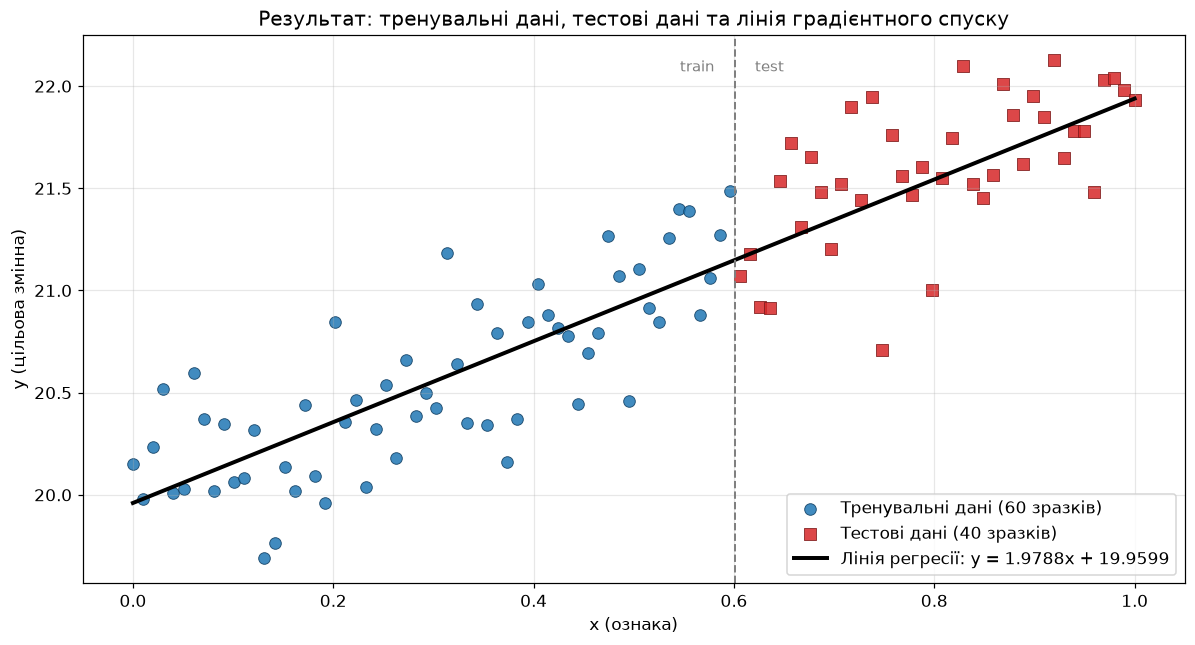

Лінія побудована ЛИШЕ за тренувальними даними (x <= 0.5960),
але добре описує й тестові точки: MSE_test = 0.075586 проти MSE_train = 0.073035.


In [12]:
# --- Спільний графік: train + test + знайдена лінія регресії ---

plt.figure(figsize=(11, 6))

# Тренувальні дані — сині круглі маркери
plt.scatter(x_train, y_train, s=58, alpha=0.85, color='#1f77b4',
            edgecolors='#0d3c61', linewidths=0.6,
            label=f'Тренувальні дані ({len(x_train)} зразків)')

# Тестові дані — червоні квадратні маркери, щоб їх було легко відрізнити
plt.scatter(x_test, y_test, s=58, alpha=0.85, color='#d62728', marker='s',
            edgecolors='#7d1a1a', linewidths=0.6,
            label=f'Тестові дані ({len(x_test)} зразків)')

# Лінія, до якої зійшовся градієнтний спуск.
# Будуємо її на всьому діапазоні x — від мінімуму train до максимуму test.
x_line = np.linspace(min(x_train.min(), x_test.min()),
                     max(x_train.max(), x_test.max()), 200)
plt.plot(x_line, predict(x_line, w_final, b_final), color='black', linewidth=2.6,
         label=f'Лінія регресії: y = {w_final:.4f}x + {b_final:.4f}')

# Вертикальна межа між областями train та test.
# Наочно показує, що праворуч від неї модель працює в режимі екстраполяції.
boundary = (x_train.max() + x_test.min()) / 2
plt.axvline(boundary, color='gray', linestyle='--', linewidth=1.3)
plt.text(boundary - 0.01, y_test.max(), 'train  ', ha='right', va='top',
         color='gray', fontsize=10)
plt.text(boundary + 0.01, y_test.max(), '  test', ha='left', va='top',
         color='gray', fontsize=10)

plt.xlabel('x (ознака)')
plt.ylabel('y (цільова змінна)')
plt.title('Результат: тренувальні дані, тестові дані та лінія градієнтного спуску')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Лінія побудована ЛИШЕ за тренувальними даними (x <= {x_train.max():.4f}),")
print(f"але добре описує й тестові точки: MSE_test = {mse_test:.6f} проти "
      f"MSE_train = {mse_train:.6f}.")

## 8. Дослідження впливу темпу навчання $\alpha$

Темп навчання — єдиний гіперпараметр батчевого градієнтного спуску, і саме він визначає, чи спуск зійдеться взагалі та як швидко.

**Теоретична межа стійкості.** Для квадратичної функції втрат градієнтний спуск збігається тоді й лише тоді, коли

$$0 < \alpha < \frac{2}{\lambda_{\max}}$$

де $\lambda_{\max}$ — найбільше власне значення матриці Гессе $\nabla^2 J$. Для MSE з ознакою $x$ та зсувом гессіан є сталою матрицею:

$$\nabla^2 J = 2 \begin{pmatrix} \overline{x^2} & \bar{x} \\ \bar{x} & 1 \end{pmatrix}$$

Обчислимо цю межу для наших даних і перевіримо її експериментом.

In [13]:
# --- Теоретична межа стійкості темпу навчання ---

# Матриця Гессе функції втрат MSE для моделі з однією ознакою та зсувом.
# Для квадратичної J вона стала — не залежить від поточних значень ваг.
# Порядок параметрів у матриці: (w, b).
hessian = 2 * np.array([
    [np.mean(x_train ** 2), np.mean(x_train)],
    [np.mean(x_train),      1.0],
])

# Власні значення симетричної матриці (eigvalsh повертає їх у зростаючому порядку)
eigvals = np.linalg.eigvalsh(hessian)
lambda_min, lambda_max = eigvals[0], eigvals[-1]

# Число обумовленості — відношення найбільшого власного значення до найменшого.
# Воно визначає, наскільки витягнутий «яр» поверхні втрат, і тим самим
# швидкість збіжності градієнтного спуску.
cond = lambda_max / lambda_min

# Теоретична межа стійкості
alpha_max = 2 / lambda_max

print(f"Середні, з яких складається гессіан: mean(x) = {np.mean(x_train):.6f}, "
      f"mean(x^2) = {np.mean(x_train ** 2):.6f}")
print("\nМатриця Гессе функції втрат:")
print(hessian)
print(f"\nВласні значення: lambda_min = {lambda_min:.6f}, lambda_max = {lambda_max:.6f}")
print(f"Число обумовленості: cond = {cond:.4f}")
print(f"\nТеоретична межа стійкості: alpha < 2 / lambda_max = {alpha_max:.6f}")
print(f"Обраний у розділі 5 темп навчання alpha = {ALPHA} < {alpha_max:.6f} — стійкий.")

Середні, з яких складається гессіан: mean(x) = 0.297980, mean(x^2) = 0.119393

Матриця Гессе функції втрат:
[[0.23878516 0.5959596 ]
 [0.5959596  2.        ]]

Власні значення: lambda_min = 0.056078, lambda_max = 2.182707
Число обумовленості: cond = 38.9225

Теоретична межа стійкості: alpha < 2 / lambda_max = 0.916293
Обраний у розділі 5 темп навчання alpha = 0.8 < 0.916293 — стійкий.


In [14]:
# --- Експеримент: збіжність за різних значень темпу навчання ---

# Набір значень alpha: від дуже малих до таких, що перевищують межу стійкості
alphas = [0.001, 0.01, 0.05, 0.1, 0.3, 0.5, 0.8, 0.9, 0.91, 0.916, 0.95, 1.0]

# Обмеження на кількість епох у цьому експерименті
MAX_EP = 50000

# Список для збереження результатів по кожному alpha
results = []

for a in alphas:
    # Навчаємо модель із поточним alpha. verbose=False, щоб не друкувати
    # десятки тисяч рядків — повний вивід за кожну епоху вже показано в розділі 5.
    # np.errstate глушить попередження про переповнення: для alpha за межею
    # стійкості ваги навмисно зростають до нескінченності, і це очікуваний
    # результат експерименту, а не помилка обчислень.
    with np.errstate(over='ignore', invalid='ignore'):
        w_a, b_a, hist_a, conv_a = gradient_descent(
            x_train, y_train, alpha=a, eps=EPS, max_epochs=MAX_EP, verbose=False
        )

    # Визначаємо статус: розбігся / зійшовся / не встиг зійтися за MAX_EP епох
    if not np.isfinite(hist_a['loss'][-1]):
        status = 'розбігся'
        mse_tr_a = mse_te_a = float('nan')
    elif conv_a:
        status = 'зійшовся'
        mse_tr_a = mse_loss(x_train, y_train, w_a, b_a)
        mse_te_a = mse_loss(x_test, y_test, w_a, b_a)
    else:
        status = f'не зійшовся за {MAX_EP}'
        mse_tr_a = mse_loss(x_train, y_train, w_a, b_a)
        mse_te_a = mse_loss(x_test, y_test, w_a, b_a)

    # Для розбіжних запусків запам'ятовуємо найбільші СКІНЧЕННІ значення ваг,
    # щоб показати, до якого порядку величини вони встигають вирости
    finite_b = [v for v in hist_a['b'] if np.isfinite(v)]
    b_max_finite = max((abs(v) for v in finite_b), default=float('nan'))

    results.append({'alpha': a, 'epochs': len(hist_a['epoch']), 'status': status,
                    'w': w_a, 'b': b_a, 'mse_train': mse_tr_a, 'mse_test': mse_te_a,
                    'b_max_finite': b_max_finite, 'history': hist_a})

# Виводимо зведену таблицю результатів
print(f"{'alpha':>7} | {'Епох':>6} | {'w':>12} | {'b':>12} | "
      f"{'MSE train':>12} | {'MSE test':>12} | Статус")
print("-" * 96)
for r in results:
    # Для розбіжних запусків ваги досягають астрономічних значень,
    # тому замість чисел друкуємо прочерк
    diverged = r['status'] == 'розбігся'
    w_s = f"{'—':>12}" if diverged else f"{r['w']:12.6f}"
    b_s = f"{'—':>12}" if diverged else f"{r['b']:12.6f}"
    tr_s = f"{'—':>12}" if diverged else f"{r['mse_train']:12.8f}"
    te_s = f"{'—':>12}" if diverged else f"{r['mse_test']:12.8f}"
    print(f"{r['alpha']:>7.3g} | {r['epochs']:>6d} | {w_s} | {b_s} | "
          f"{tr_s} | {te_s} | {r['status']}")

print(f"\nТеоретична межа стійкості alpha_max = {alpha_max:.6f}")

# Показуємо, наскільки великими стають ваги при розбіжності
for r in results:
    if r['status'] == 'розбігся':
        print(f"  alpha = {r['alpha']:g}: ваги зростають до |b| ~ {r['b_max_finite']:.2e} "
              f"(порядок 10^{int(np.floor(np.log10(r['b_max_finite'])))}), "
              f"далі настає переповнення на епосі {r['epochs']}")

  alpha |   Епох |            w |            b |    MSE train |     MSE test | Статус
------------------------------------------------------------------------------------------------
  0.001 |  50000 |     2.208017 |    19.889648 |   0.07464693 |   0.07882396 | не зійшовся за 50000
   0.01 |  21946 |     1.978802 |    19.959920 |   0.07303507 |   0.07558634 | зійшовся
   0.05 |   4385 |     1.978802 |    19.959920 |   0.07303507 |   0.07558634 | зійшовся
    0.1 |   2190 |     1.978802 |    19.959920 |   0.07303507 |   0.07558634 | зійшовся
    0.3 |    726 |     1.978802 |    19.959920 |   0.07303507 |   0.07558634 | зійшовся
    0.5 |    433 |     1.978802 |    19.959920 |   0.07303507 |   0.07558634 | зійшовся
    0.8 |    269 |     1.978801 |    19.959920 |   0.07303507 |   0.07558636 | зійшовся
    0.9 |    486 |     1.978785 |    19.959925 |   0.07303507 |   0.07558716 | зійшовся
   0.91 |   1271 |     1.978785 |    19.959926 |   0.07303507 |   0.07558706 | зійшовся
  0.916 |  27

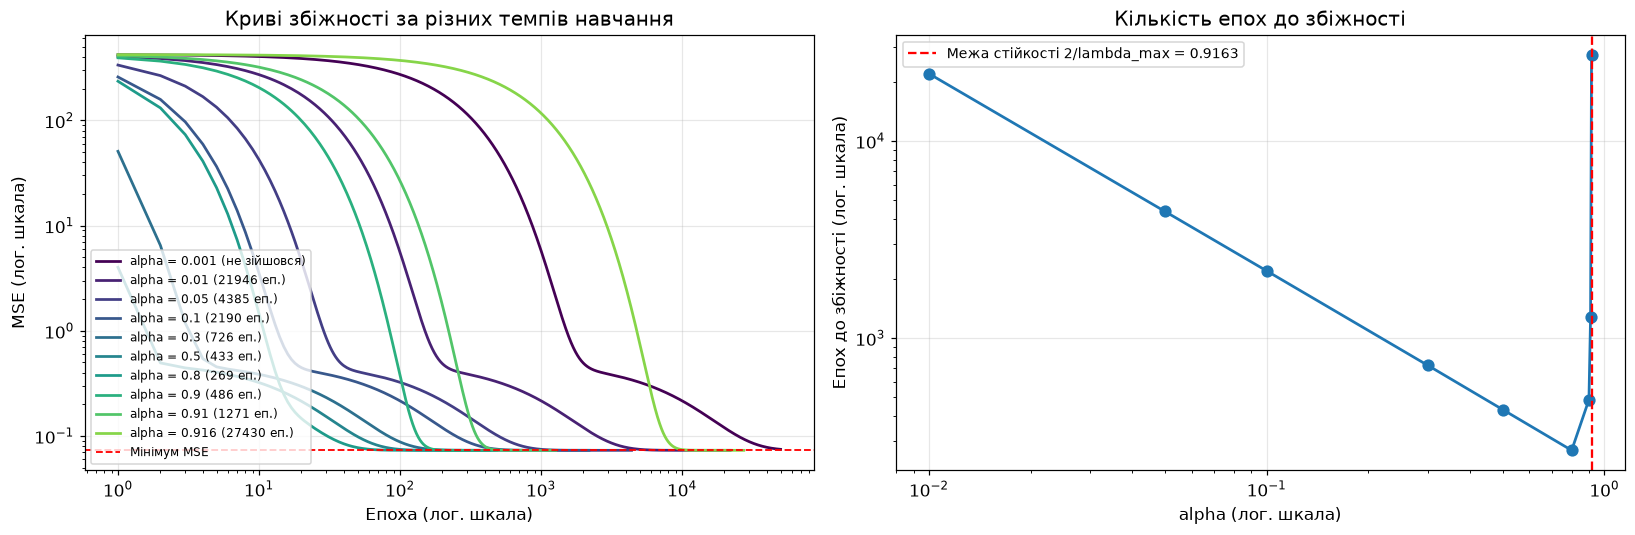

Найшвидша збіжність серед перебраних значень: alpha = 0.8 за 269 епох.
Це значення й використано для основної моделі в розділі 5.

При alpha = 0.001 модель не зійшлася навіть за 50000 епох,
а при alpha >= 0.95 > 0.9163 спуск розбігається — експеримент підтверджує теоретичну межу.

Залежність від alpha НЕ монотонна: біля межі стійкості збіжність
знову сповільнюється через коливання поперек «яру»:
  alpha = 0.8    ->    269 епох
  alpha = 0.9    ->    486 епох
  alpha = 0.91   ->   1271 епох
  alpha = 0.916  ->  27430 епох


In [15]:
# --- Графік: криві збіжності для різних alpha ---

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Підграфік 1: MSE за епохами для кожного alpha (обидві шкали логарифмічні) ---
cmap = plt.get_cmap('viridis')
for i, r in enumerate(results):
    # Розбіжні запуски не малюємо — їхні втрати швидко стають нескінченними
    if r['status'] == 'розбігся':
        continue
    # У легенді окремо позначаємо запуски, які не встигли зійтися за MAX_EP епох
    tag = f"{r['epochs']} еп." if r['status'] == 'зійшовся' else 'не зійшовся'
    axes[0].plot(r['history']['epoch'], r['history']['loss'],
                 color=cmap(i / max(1, len(results) - 1)), linewidth=1.8,
                 label=f"alpha = {r['alpha']:g} ({tag})")

# Горизонтальна лінія — мінімально досяжне значення MSE на train
axes[0].axhline(mse_train, color='red', linestyle='--', linewidth=1.2,
                label='Мінімум MSE')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Епоха (лог. шкала)')
axes[0].set_ylabel('MSE (лог. шкала)')
axes[0].set_title('Криві збіжності за різних темпів навчання')
axes[0].legend(fontsize=8, loc='lower left')

# --- Підграфік 2: кількість епох до збіжності залежно від alpha ---
# Беремо лише ті запуски, що реально зійшлися
conv_res = [r for r in results if r['status'] == 'зійшовся']
axes[1].plot([r['alpha'] for r in conv_res], [r['epochs'] for r in conv_res],
             marker='o', color='#1f77b4', linewidth=1.8, markersize=7)
# Вертикальна лінія — теоретична межа стійкості
axes[1].axvline(alpha_max, color='red', linestyle='--', linewidth=1.5,
                label=f'Межа стійкості 2/lambda_max = {alpha_max:.4f}')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('alpha (лог. шкала)')
axes[1].set_ylabel('Епох до збіжності (лог. шкала)')
axes[1].set_title('Кількість епох до збіжності')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Знаходимо найкраще alpha — те, що дало найменшу кількість епох
best = min(conv_res, key=lambda r: r['epochs'])
print(f"Найшвидша збіжність серед перебраних значень: alpha = {best['alpha']} "
      f"за {best['epochs']} епох.")
print(f"Це значення й використано для основної моделі в розділі 5.")
print(f"\nПри alpha = 0.001 модель не зійшлася навіть за {MAX_EP} епох,")
print(f"а при alpha >= 0.95 > {alpha_max:.4f} спуск розбігається — "
      f"експеримент підтверджує теоретичну межу.")

# Окремо показуємо поведінку біля самої межі стійкості
near = {r['alpha']: r['epochs'] for r in conv_res}
print(f"\nЗалежність від alpha НЕ монотонна: біля межі стійкості збіжність")
print(f"знову сповільнюється через коливання поперек «яру»:")
for a in [0.8, 0.9, 0.91, 0.916]:
    if a in near:
        print(f"  alpha = {a:<6g} -> {near[a]:6d} епох")

## 9. Обумовленість задачі та масштабування ознаки

Виникає природне питання: чому для задачі всього з двома параметрами потрібні сотні епох?

Причина — **погана обумовленість**. Важливо, що гессіан залежить **виключно від ознаки** $x$ — змінна $y$ у його формулу не входить зовсім:

$$\nabla^2 J = 2 \begin{pmatrix} \overline{x^2} & \bar{x} \\ \bar{x} & 1 \end{pmatrix}$$

Друга вага $b$ — це, по суті, коефіцієнт при сталій ознаці-одиниці, і саме тому в правому нижньому куті стоїть $1$. Ознака $x$ з цією одиницею не узгоджена за двома параметрами одразу: вона **не центрована** ($\bar{x} = 0.298 \ne 0$, тому позадіагональні елементи не нульові) і має **інший масштаб** ($\overline{x^2} = 0.119$ проти $1$). Через це власні значення гессіана відрізняються майже 40 разів, а лінії рівня MSE утворюють витягнутий «яр» (добре видно на графіку в розділі 5).

Швидкість збіжності обмежена числом обумовленості: за оптимально підібраного сталого кроку $\alpha = 2/(\lambda_{\min} + \lambda_{\max})$ справедлива оцінка

$$\|\theta_k - \theta^*\| \le \left( \frac{\text{cond} - 1}{\text{cond} + 1} \right)^k \|\theta_0 - \theta^*\|$$

Велике значення $y \approx 20$ на обумовленість **не** впливає: воно лише відсуває оптимум $b^* \approx 20$ далеко від точки старту $b_0 = 0$, через що потрібно більше ітерацій — але форму поверхні втрат не змінює.

**Стандартизація ознаки** $x' = \dfrac{x - \bar{x}}{\sigma_x}$ робить гессіан діагональним з однаковими власними значеннями, тобто $\text{cond} = 1$, і лінії рівня стають концентричними колами. Перевіримо це експериментально. Після навчання на стандартизованій ознаці ваги перераховуються назад у початковий масштаб:

$$w = \frac{w'}{\sigma_x}, \qquad b = b' - \frac{w' \bar{x}}{\sigma_x}$$

In [16]:
# --- Експеримент: градієнтний спуск на стандартизованій ознаці ---

# Параметри стандартизації обчислюємо ЛИШЕ на тренувальних даних,
# інакше інформація про тестову вибірку просочилася б у процес навчання
x_mean, x_std = x_train.mean(), x_train.std()

# Стандартизуємо ознаку: віднімаємо середнє й ділимо на стандартне відхилення
x_train_std = (x_train - x_mean) / x_std

# Гессіан для стандартизованої ознаки
hessian_std = 2 * np.array([
    [np.mean(x_train_std ** 2), np.mean(x_train_std)],
    [np.mean(x_train_std),      1.0],
])
eig_std = np.linalg.eigvalsh(hessian_std)

# Перевіряємо, ЩО САМЕ псує обумовленість: центрування, масштаб чи обидва разом.
# Гессіан не містить y, тому експериментуємо лише з перетвореннями ознаки x.
def cond_of(xx):
    """Число обумовленості гессіана MSE для заданого варіанта ознаки."""
    H = 2 * np.array([[np.mean(xx ** 2), np.mean(xx)], [np.mean(xx), 1.0]])
    ev = np.linalg.eigvalsh(H)
    return ev[-1] / ev[0]


print("Що саме псує обумовленість задачі:")
print(f"  вихідна ознака x                      : cond = {cond_of(x_train):8.4f}")
print(f"  лише центрована (mean = 0)            : cond = {cond_of(x_train - x_mean):8.4f}")
print(f"  лише масштабована (std = 1)           : cond = {cond_of(x_train / x_std):8.4f}")
print(f"  центрована + масштабована             : cond = {cond_of(x_train_std):8.4f}")
print("\nЖодного з двох перетворень окремо НЕ достатньо — потрібні обидва.")
print("Зауважимо також, що y тут ніде не використовується: гессіан від нього не залежить.\n")

print("Гессіан після стандартизації ознаки:")
print(np.round(hessian_std, 10))
print(f"\nВласні значення: {np.round(eig_std, 8)}")
print(f"Число обумовленості: {eig_std[-1] / eig_std[0]:.6f} "
      f"(було {cond:.4f} для вихідної ознаки)")

# Навчаємо модель на стандартизованій ознаці з тим самим критерієм збіжності
w_s, b_s, hist_s, conv_s = gradient_descent(
    x_train_std, y_train, alpha=0.5, eps=EPS, verbose=False
)

# Перераховуємо ваги назад у початковий масштаб ознаки x
w_back = w_s / x_std
b_back = b_s - w_s * x_mean / x_std

print(f"\nКількість епох до збіжності на стандартизованій ознаці (alpha = 0.5): "
      f"{len(hist_s['epoch'])}")
print(f"Для порівняння, на вихідній ознаці: {len(history['epoch'])} "
      f"(alpha = {ALPHA})")
print(f"Прискорення: у {len(history['epoch']) / len(hist_s['epoch']):.0f} разів")

# Чому достатньо буквально одного кроку: після стандартизації обидва власні
# значення гессіана рівні 2, тому крок alpha = 0.5 = 1/lambda переводить
# ваги точно в мінімум — це збігається з кроком методу Ньютона.
print(f"\nОдного кроку достатньо не випадково: обидва власні значення гессіана")
print(f"рівні {eig_std[0]:.0f}, тому alpha = 0.5 = 1/lambda дає крок, що точно")
print(f"переводить ваги в мінімум (це збігається з кроком методу Ньютона).")

print(f"\nВаги, перераховані у вихідний масштаб:")
print(f"  w = {w_back:.10f}   (на вихідній ознаці: {w_final:.10f})")
print(f"  b = {b_back:.10f}   (на вихідній ознаці: {b_final:.10f})")
print(f"\nMSE test = {mse_loss(x_test, y_test, w_back, b_back):.10f} "
      f"(на вихідній ознаці: {mse_test:.10f})")
print("\nРозв'язок ТОЙ САМИЙ — стандартизація не змінює оптимум, а лише")
print("змінює геометрію задачі й тим самим різко прискорює збіжність.")

Що саме псує обумовленість задачі:
  вихідна ознака x                      : cond =  38.9225
  лише центрована (mean = 0)            : cond =  32.6791
  лише масштабована (std = 1)           : cond =  21.9806
  центрована + масштабована             : cond =   1.0000

Жодного з двох перетворень окремо НЕ достатньо — потрібні обидва.
Зауважимо також, що y тут ніде не використовується: гессіан від нього не залежить.

Гессіан після стандартизації ознаки:
[[2. 0.]
 [0. 2.]]

Власні значення: [2. 2.]
Число обумовленості: 1.000000 (було 38.9225 для вихідної ознаки)

Кількість епох до збіжності на стандартизованій ознаці (alpha = 0.5): 1
Для порівняння, на вихідній ознаці: 269 (alpha = 0.8)
Прискорення: у 269 разів

Одного кроку достатньо не випадково: обидва власні значення гессіана
рівні 2, тому alpha = 0.5 = 1/lambda дає крок, що точно
переводить ваги в мінімум (це збігається з кроком методу Ньютона).

Ваги, перераховані у вихідний масштаб:
  w = 1.9787849545   (на вихідній ознаці: 1.978801

## 10. Перевірка: порівняння з аналітичним розв'язком

Для лінійної регресії з MSE оптимум можна знайти й точно, без ітерацій — прирівнявши градієнт до нуля, отримуємо систему **нормальних рівнянь**:

$$X^{T} X \theta = X^{T} y, \qquad \theta = (w, b)^{T}$$

Умова вимагає використати саме градієнтний спуск, тому аналітичний розв'язок застосовуємо **виключно як контрольну перевірку**: якщо спуск справді зійшовся до глобального мінімуму, його ваги мають збігатися з нормальними рівняннями.

In [17]:
# --- Аналітичний розв'язок через нормальні рівняння (контрольна перевірка) ---

# Формуємо матрицю плану X: перший стовпець — ознака x, другий — одиниці для зсуву b
X = np.column_stack([x_train, np.ones(len(x_train))])

# Розв'язуємо систему нормальних рівнянь (X^T X) theta = X^T y
theta = np.linalg.solve(X.T @ X, X.T @ y_train)
w_exact, b_exact = theta[0], theta[1]

print("Порівняння розв'язків:")
print(f"{'':<26} {'w':>16} {'b':>16}")
print("-" * 60)
print(f"{'Градієнтний спуск':<26} {w_final:>16.10f} {b_final:>16.10f}")
print(f"{'Нормальні рівняння':<26} {w_exact:>16.10f} {b_exact:>16.10f}")
print(f"{'Абсолютна різниця':<26} {abs(w_final - w_exact):>16.3e} "
      f"{abs(b_final - b_exact):>16.3e}")

# Порівнюємо також значення функції втрат
mse_exact_train = mse_loss(x_train, y_train, w_exact, b_exact)
mse_exact_test = mse_loss(x_test, y_test, w_exact, b_exact)

print(f"\n{'':<26} {'MSE train':>16} {'MSE test':>16}")
print("-" * 60)
print(f"{'Градієнтний спуск':<26} {mse_train:>16.10f} {mse_test:>16.10f}")
print(f"{'Нормальні рівняння':<26} {mse_exact_train:>16.10f} {mse_exact_test:>16.10f}")
print(f"{'Різниця':<26} {abs(mse_train - mse_exact_train):>16.3e} "
      f"{abs(mse_test - mse_exact_test):>16.3e}")

print("\nВаги збігаються з точним розв'язком до 5-6 знака, а значення MSE —")
print("до похибки округлення. Це доводить, що градієнтний спуск зійшовся")
print("саме до глобального мінімуму функції втрат, а не зупинився передчасно.")

Порівняння розв'язків:
                                          w                b
------------------------------------------------------------
Градієнтний спуск              1.9788013885    19.9599202118
Нормальні рівняння             1.9787849545    19.9599252501
Абсолютна різниця                 1.643e-05        5.038e-06

                                  MSE train         MSE test
------------------------------------------------------------
Градієнтний спуск              0.0730350678     0.0755863635
Нормальні рівняння             0.0730350678     0.0755871111
Різниця                           8.284e-12        7.476e-07

Ваги збігаються з точним розв'язком до 5-6 знака, а значення MSE —
до похибки округлення. Це доводить, що градієнтний спуск зійшовся
саме до глобального мінімуму функції втрат, а не зупинився передчасно.


## Висновки

1. **Лінійну регресію та батчевий градієнтний спуск реалізовано з нуля** — лише засобами Python, NumPy та Matplotlib, без pandas і scikit-learn. Аналітичні формули градієнта MSE перевірено порівнянням із чисельною похідною: розбіжність на рівні $10^{-9}$, тобто похибки округлення.

2. **Використано саме класичний (батчевий) градієнтний спуск:** градієнт обчислюється по всій тренувальній вибірці з 60 зразків, і за одну епоху виконується рівно одне оновлення ваг. Після кожної епохи виводяться поточні значення $w$, $b$ та MSE, як вимагає умова.

3. **Спуск зійшовся за 269 епох** при $\alpha = 0.8$ та критерії $\|\nabla J\|_2 < 10^{-6}$. Знайдена модель: $\hat{y} = 1.978801 x + 19.959920$. Втрати впали з $422.477$ у початковій точці ($w = b = 0$) до $0.0730350678$ — у 5785 разів, а норма градієнта — з $42.9$ до $9.6 \cdot 10^{-7}$.

4. **Якість на незалежних тестових даних:** $MSE_{test} = 0.0755863635$ проти $MSE_{train} = 0.0730350678$, тобто лише на 3.5 % більше. RMSE $= 0.2749$ при повному розмаху $y$, що становить $2.4403$ — тобто типова помилка прогнозу дорівнює 11.3 % розмаху. Перенавчання немає, модель узагальнює добре — і це при тому, що вибірки розділені **за значенням $x$** (train: $x \in [0;\ 0.596]$, test: $x \in [0.606;\ 1.0]$), а не випадково, тому на тесті модель працює в режимі екстраполяції за межі навчального діапазону. Саме екстраполяцією й пояснюється невеликий додатний зсув залишків на тесті ($+0.0488$ проти $+1.4 \cdot 10^{-7}$ на train) — модель дещо занижує прогноз у правій частині діапазону.

5. **Коефіцієнт детермінації** $R^2 = 0.6213$ на train та $0.3729$ на test. Невисокі значення пояснюються не слабкістю моделі, а власною природою даних: шум у них ($\sigma \approx 0.27$) співмірний із зміною сигналу на діапазоні ($2 \cdot 0.6 \approx 1.2$). Аналіз залишків підтверджує адекватність лінійної моделі — залишки симетрично розкидані навколо нуля без структури, їхнє середнє на train нульове.

6. **Темп навчання виявився критичним гіперпараметром.** Експеримент повністю підтвердив теорію: спуск збігається лише при $\alpha < 2/\lambda_{\max} = 0.9163$, і вже при $\alpha = 0.95$ ваги встигають вирости до порядку $10^{153}$, після чого обчислення переповнюється. Занадто малий $\alpha = 0.001$ не дав збіжності навіть за 50 000 епох. Залежність кількості епох від $\alpha$ **не монотонна**: оптимум — $\alpha = 0.8$ (269 епох), далі збіжність знову сповільнюється через коливання поперек «яру» ($\alpha = 0.9$ — 486 епох, $\alpha = 0.916$ на самій межі — вже десятки тисяч епох).

7. **Причина великої кількості епох — погана обумовленість задачі:** $\text{cond}(\nabla^2 J) = 38.92$. Гессіан залежить лише від ознаки $x$ ($y$ у його формулу не входить зовсім), і ця ознака не узгоджена зі сталою ознакою-одиницею, що відповідає зсуву $b$, одразу за двома параметрами: вона не центрована ($\bar{x} = 0.298$) і має інший масштаб ($\overline{x^2} = 0.119$ проти $1$). Окремий експеримент показав, що жодного з двох перетворень не достатньо: лише центрування дає $\text{cond} = 32.68$, лише масштабування — $21.98$, і тільки обидва разом — $1.0$. Велике $y \approx 20$ на обумовленість не впливає — воно лише відсуває оптимум від точки старту. Лінії рівня MSE утворюють витягнутий «яр», і траєкторія спуску спочатку коливається поперек нього, а потім поволі сповзає дном. **Стандартизація ознаки** зменшує число обумовленості до $1.0$ і скорочує навчання з 269 епох до **однієї** — при абсолютно тому самому кінцевому розв'язку. Одного кроку достатньо не випадково: після стандартизації обидва власні значення гессіана рівні $2$, тому $\alpha = 0.5 = 1/\lambda$ переводить ваги точно в мінімум (це збігається з кроком методу Ньютона). Це найпрактичніший висновок роботи: масштабування ознак не змінює оптимум, але радикально впливає на швидкість його досягнення.

8. **Правильність розв'язку доведено незалежно:** ваги, знайдені градієнтним спуском, збігаються з точним розв'язком нормальних рівнянь ($w^* = 1.9787849545$, $b^* = 19.9599252501$) з точністю $1.6 \cdot 10^{-5}$ за $w$ та $5.0 \cdot 10^{-6}$ за $b$, а значення MSE — до похибки округлення. Отже спуск дійшов саме до глобального мінімуму, що й очікувано: функція втрат MSE для лінійної регресії строго випукла й локальних мінімумів не має.